In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from rapidfuzz import process, fuzz

In [169]:
pd.options.display.float_format = '{:,.2f}'.format

In [170]:
df_sales = pd.read_excel("../Dataset/Superstore.xlsx")

In [171]:
df_sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [172]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [173]:
df_sales[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


# 1. Pre-Processing

#### Missing Values

In [174]:
df_sales[df_sales.isna().any(axis=1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [175]:
(df_sales['Sales'] == 0).sum()

np.int64(0)

In [176]:
df_sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [177]:
categorical1 = [
    'Ship Mode', 'Segment', 'Country', 
    'State', 'Region', 'Category', 
    'Sub-Category'
]

categorical2 = [
    'Customer Name', 'City', 'Product Name'
]

#### Inconsistent Data in Categorical Features

In [178]:
for col in categorical1:
    print(f"{col} ({df_sales[col].nunique()}): {df_sales[col].unique()}")

Ship Mode (4): <StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
Segment (3): <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Country (1): <StringArray>
['United States']
Length: 1, dtype: str
State (49): <StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',            'Louisiana'

In [179]:
def normalize_text(s):
    return(
        s.astype(str).
            str.strip().
            str.lower().
            str.replace(r'\s+', ' ', regex=True)
    )

In [180]:
audit = []

for col in categorical2:
    s = df_sales[col]

    audit.append({
        "column" : col,
        "unique_raw" : s.nunique(),
        "unique_lower" : s.str.lower().nunique(),
        "unique_trim" : s.str.strip().nunique(),
        "unique_norm" : normalize_text(s).nunique(),
    })

audit_df = pd.DataFrame(audit)
audit_df

,column,unique_raw,unique_lower,unique_trim,unique_norm
0,Customer Name,793,793,793,793
1,City,531,531,531,531
2,Product Name,1841,1841,1841,1841


In [181]:
for col in categorical2:
    min_len = df_sales[col].str.len().min()
    min_values = df_sales.loc[df_sales[col].str.len() == min_len, col].unique()
    print(f"column : {col}, min : {min_len}, value : {min_values}")

column : Customer Name, min : 7, value : <StringArray>
['Jim Epp', 'Amy Cox']
Length: 2, dtype: str
column : City, min : 4, value : <StringArray>
['Orem', 'Troy', 'Mesa', 'Cary', 'Reno', 'Kent', 'York', 'Rome', 'Yuma',
 'Lehi', 'Waco', 'Lodi']
Length: 12, dtype: str
column : Product Name, min : 5, value : <StringArray>
['LG G3', 'LG G2']
Length: 2, dtype: str


In [182]:
def find_similar(values, threshold = 90):
    values = list(values)
    seen = set()
    groups = []

    for v in values:
        if v in seen:
            continue
        matches = process.extract(v, values, scorer=fuzz.ratio)
        close = [m[0] for m in matches if m[1] >= threshold]

        if len(close) > 1:
            groups.append(close)
            seen.update(close)

    return groups

In [183]:
for col in categorical2:
    vals = df_sales[col].unique()
    print(f"Column : {col}")
    find_similar(vals, 92)

Column : Customer Name
Column : City
Column : Product Name


In [184]:
for col in categorical2:
    vc = df_sales[col].value_counts()
    rare = vc[vc <= 3]

    if len(rare) > 0:
        print(f"\n{col} - rare labels:")
        print(rare.head(10))


Customer Name - rare labels:
Customer Name
Gene Hale           3
Adrian Shami        3
Paul Knutson        3
Joel Jenkins        3
Greg Hansen         3
Mitch Willingham    3
Brad Thomas         3
Larry Tron          3
Larry Hughes        3
Jim Radford         3
Name: count, dtype: int64

City - rare labels:
City
Urbandale         3
Taylor            3
Canton            3
Park Ridge        3
Sierra Vista      3
Farmington        3
Boca Raton        3
Homestead         3
Cuyahoga Falls    3
Escondido         3
Name: count, dtype: int64

Product Name - rare labels:
Product Name
Imation 8GB Mini TravelDrive USB 2.0 Flash Drive                                                   3
Plantronics HL10 Handset Lifter                                                                    3
Turquoise Lead Holder with Pocket Clip                                                             3
Avery Personal Creations Heavyweight Cards                                                         3
Xerox 1921  

#### Data Duplicates

In [185]:
df_sales[df_sales.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


# 2. EDA

## 2.1 Sales, Profit, Margin

In [186]:
df_sales.loc[:, 'Margin'] = df_sales.loc[:,'Profit'] / df_sales.loc[:,'Sales']

In [187]:
print(f"Total Sales  : $ {df_sales['Sales'].sum():,.0f}\nTotal Profit : $ {df_sales['Profit'].sum():,.0f}\nMargin\t     : {(df_sales['Profit'].sum() / df_sales['Sales'].sum()):.2f}")

Total Sales  : $ 2,297,201
Total Profit : $ 286,397
Margin	     : 0.12


In [188]:
df_sales.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

,Total_Sales,Total_Profit,Margin
Region,,,
Central,"501,239.89","39,706.36",0.08
East,"678,781.24","91,522.78",0.13
South,"391,721.91","46,749.43",0.12
West,"725,457.82","108,418.45",0.15


In [189]:
df_sales.groupby('Ship Mode').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

,Total_Sales,Total_Profit,Margin
Ship Mode,,,
First Class,"351,428.42","48,969.84",0.14
Same Day,"128,363.12","15,891.76",0.12
Second Class,"459,193.57","57,446.64",0.13
Standard Class,"1,358,215.74","164,088.79",0.12


In [190]:
df_sales.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

,Total_Sales,Total_Profit,Margin
Segment,,,
Consumer,"1,161,401.34","134,119.21",0.12
Corporate,"706,146.37","91,979.13",0.13
Home Office,"429,653.15","60,298.68",0.14


<function matplotlib.pyplot.show(close=None, block=None)>

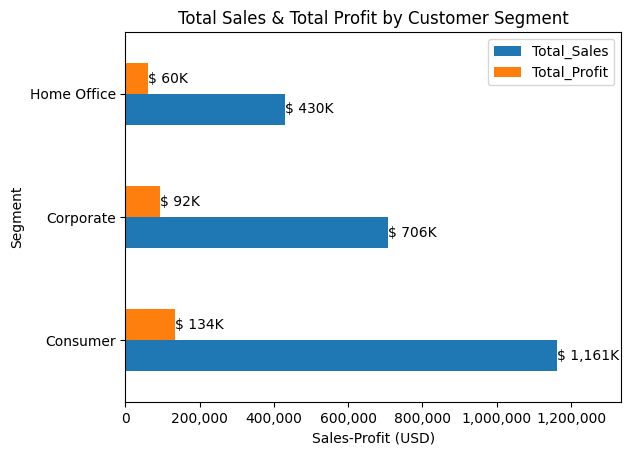

In [191]:
ax = df_sales.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).plot(kind='barh')

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title("Total Sales & Total Profit by Customer Segment")
ax.set_xlabel("Sales-Profit (USD)")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'$ {v/1000:,.0f}K' for v in container.datavalues]
    ax.bar_label(container, labels = labels)

fig = ax.get_figure()
fig.savefig("../Images/sales_&_profit_by_customer_segment.png", dpi = 300, bbox_inches='tight')

plt.show

### The customer segment analysis shows a consistent pattern in which the Consumer segment remains the most dominant in terms of sales contribution.

In [192]:
df_sales.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

,Total_Sales,Total_Profit,Margin
Category,,,
Furniture,"741,999.80","18,451.27",0.02
Office Supplies,"719,047.03","122,490.80",0.17
Technology,"836,154.03","145,454.95",0.17


### Technology and Office Supplies demonstrate healthier profitability compared to Furniture.

In [193]:
df_sales.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
).sort_values(by='Margin')

,Total_Sales,Total_Profit,Margin
Sub-Category,,,
Tables,"206,965.53","-17,725.48",-0.09
Bookcases,"114,880.00","-3,472.56",-0.03
Supplies,"46,673.54","-1,189.10",-0.03
Machines,"189,238.63","3,384.76",0.02
Chairs,"328,449.10","26,590.17",0.08
Storage,"223,843.61","21,278.83",0.10
Phones,"330,007.05","44,515.73",0.13
Furnishings,"91,705.16","13,059.14",0.14
Binders,"203,412.73","30,221.76",0.15


In [194]:
SubCat_Sales = df_sales.groupby('Sub-Category')['Sales'].agg('sum')

Bottom_Sub_Cat_Sales = SubCat_Sales.sort_values().head(5)
Top_Sub_Cat_Sales = SubCat_Sales.sort_values(ascending=False).head(5)

Sub_Cat_by_sales = pd.concat([Top_Sub_Cat_Sales, Bottom_Sub_Cat_Sales]).sort_values()

In [195]:
Sub_Cat_by_sales

Sub-Category
Fasteners     3,024.28
Labels       12,486.31
Envelopes    16,476.40
Art          27,118.79
Supplies     46,673.54
Binders     203,412.73
Tables      206,965.53
Storage     223,843.61
Chairs      328,449.10
Phones      330,007.05
Name: Sales, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

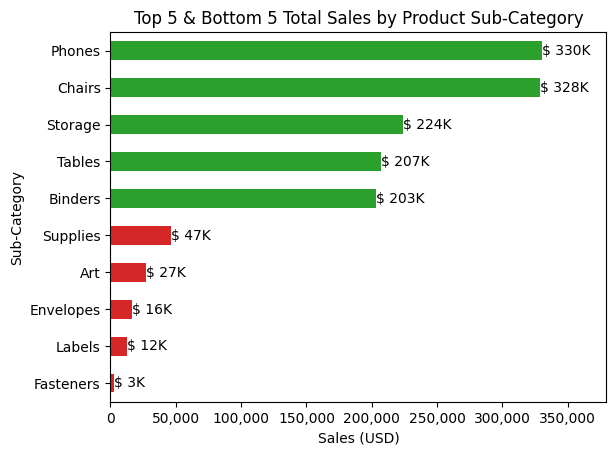

In [196]:
colors =  ['tab:red']*5 + ['tab:green']*5

ax = Sub_Cat_by_sales.plot(kind='barh', color=colors)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title("Top 5 & Bottom 5 Total Sales by Product Sub-Category")
ax.set_xlabel("Sales (USD)")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'$ {v/1000:,.0f}K' for v in container.datavalues]
    ax.bar_label(container, labels = labels)

fig = ax.get_figure()
fig.savefig("../Images/top_&_bottom_sales_by_product_subcategory.png", dpi = 300, bbox_inches='tight')

plt.show

### Out of 17 sub-categories, the top five in sales generate over USD 1.2 billion in revenue, while the bottom five produce less than USD 150K.

In [197]:
SubCat_Profit = df_sales.groupby('Sub-Category')['Profit'].agg('sum')

Bottom_Sub_Cat_Profit = SubCat_Profit.sort_values().head(5)
Top_Sub_Cat_Profit = SubCat_Profit.sort_values(ascending=False).head(5)

Sub_Cat_by_profit = pd.concat([Top_Sub_Cat_Profit, Bottom_Sub_Cat_Profit]).sort_values()

In [198]:
Sub_Cat_by_profit

Sub-Category
Tables        -17,725.48
Bookcases      -3,472.56
Supplies       -1,189.10
Fasteners         949.52
Machines        3,384.76
Binders        30,221.76
Paper          34,053.57
Accessories    41,936.64
Phones         44,515.73
Copiers        55,617.82
Name: Profit, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

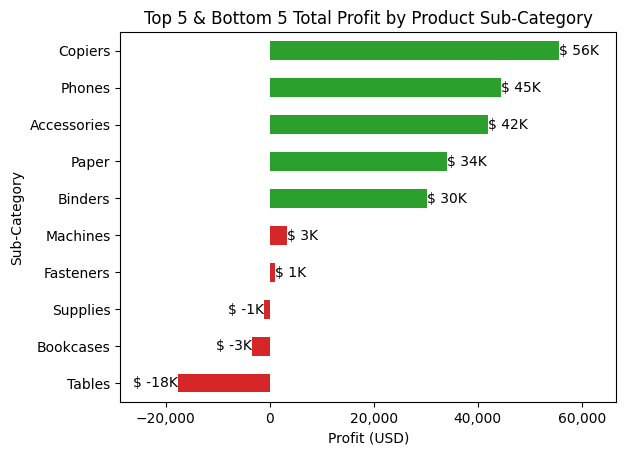

In [199]:
colors =  ['tab:red']*5 + ['tab:green']*5

ax = Sub_Cat_by_profit.plot(kind='barh', color=colors)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title("Top 5 & Bottom 5 Total Profit by Product Sub-Category")
ax.set_xlabel("Profit (USD)")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'$ {v/1000:,.0f}K' for v in container.datavalues]
    ax.bar_label(container, labels = labels)
    
fig = ax.get_figure()
fig.savefig("../Images/top_&_bottom_profit_by_product_subcategory.png", dpi = 300, bbox_inches='tight')

plt.show

### Although Tables rank among the top five sub-categories in sales, they generate the largest negative profit (loss).

In [200]:
SubCat_Margin = df_sales.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
).sort_values(by='Margin')

SubCat_Margin = SubCat_Margin['Margin']
Bottom_Sub_Cat_Margin = SubCat_Margin.sort_values().head(5)
Top_Sub_Cat_Margin = SubCat_Margin.sort_values(ascending=False).head(5)

Sub_Cat_by_margin = pd.concat([Top_Sub_Cat_Margin, Bottom_Sub_Cat_Margin]).sort_values()

In [201]:
Sub_Cat_by_margin

Sub-Category
Tables      -0.09
Bookcases   -0.03
Supplies    -0.03
Machines     0.02
Chairs       0.08
Fasteners    0.31
Copiers      0.37
Envelopes    0.42
Paper        0.43
Labels       0.44
Name: Margin, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

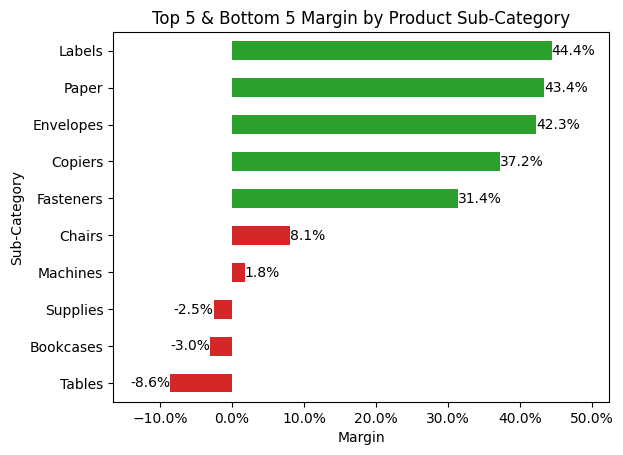

In [202]:
colors =  ['tab:red']*5 + ['tab:green']*5

ax = Sub_Cat_by_margin.plot(kind='barh', color=colors)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1))
ax.set_title("Top 5 & Bottom 5 Margin by Product Sub-Category")
ax.set_xlabel("Margin")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'{v*100:.1f}%' for v in container.datavalues]
    ax.bar_label(container, labels = labels)

fig = ax.get_figure()
fig.savefig("../Images/top_&_bottom_margin_by_product_subcategory.png", dpi = 300, bbox_inches='tight')

plt.show

### As shown in the profit chart, Supplies, Bookcases, and Tables generate losses rather than profits.

<Axes: ylabel='Frequency'>

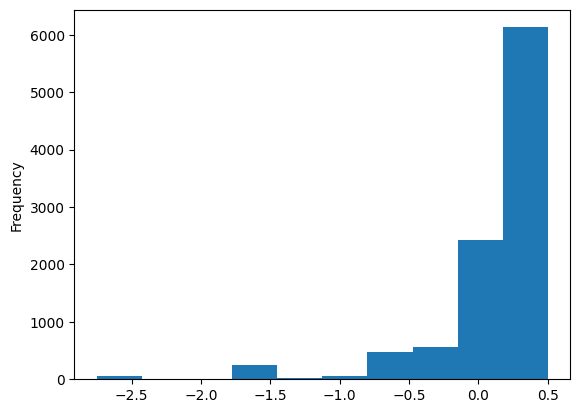

In [203]:
df_sales['Margin'].plot(kind='hist')

In [204]:
Margin_df = df_sales.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

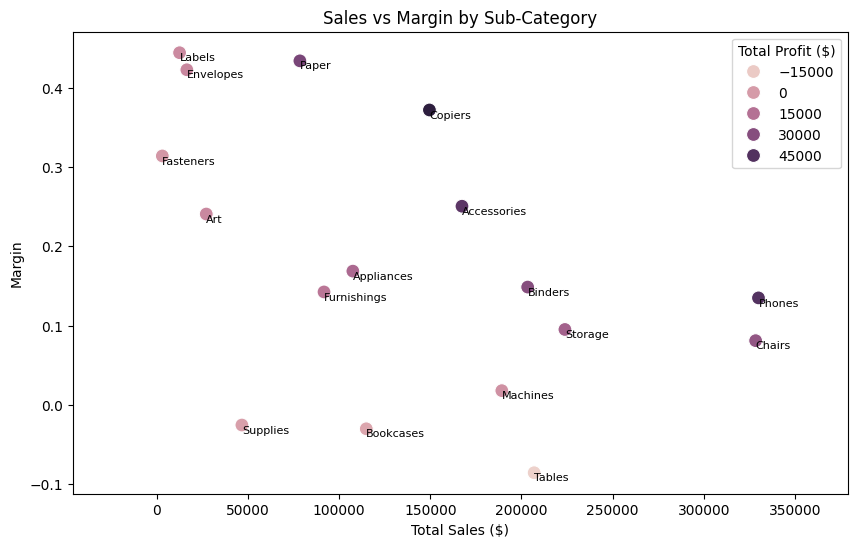

In [205]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Sales', y='Margin', hue='Total_Profit', data=Margin_df, s=100)

for i in Margin_df.index:
    plt.text(
        Margin_df.loc[i, 'Total_Sales'],
        Margin_df.loc[i, 'Margin'],
        i,
        fontsize=8,
        va='top',
        ha='left'
    )

plt.title("Sales vs Margin by Sub-Category")
plt.xlabel("Total Sales ($)")
plt.legend(title="Total Profit ($)")
plt.margins(x=0.15)

plt.savefig("../Images/sales_vs_margin_vs_profit_by_product_subcategory.png", dpi = 300, bbox_inches='tight')

plt.show()

### Tables and Bookcases indicate that high sales volume is not always directly proportional to profitability.

## 2.2. Discount

In [206]:
bins = [-0.01, 0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ['0%', '1-20%', '20-40%', '40-60%', '60-80%', '80%+']
df_sales.loc[:, 'Discount Group'] = pd.cut(df_sales['Discount'], bins=bins, labels=labels)

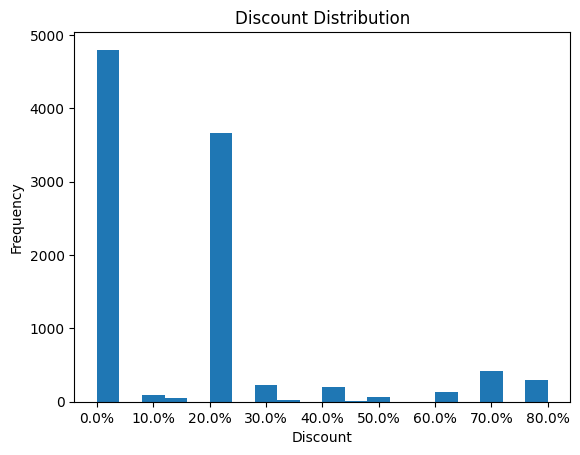

In [207]:
ax = df_sales['Discount'].plot(kind='hist', bins=20)
ax.set_title("Discount Distribution")
ax.set_xlabel("Discount")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1))

fig = ax.get_figure()
fig.savefig("../Images/discount_distribution.png", dpi = 300, bbox_inches='tight')

plt.show()

In [208]:
df_sales.groupby('Discount Group').agg(
    Avg_Sales=('Sales', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum')
).assign(Margin=lambda d:
         d.Total_Profit / d.Total_Sales
)

,Avg_Sales,Total_Sales,Avg_Profit,Total_Profit,Margin
Discount Group,,,,,
0%,226.74,"1,087,908.47",66.90,"320,987.60",0.30
1-20%,222.59,"846,522.24",26.50,"100,785.47",0.12
20-40%,509.00,"234,137.90",-77.86,"-35,817.47",-0.15
40-60%,330.46,"71,048.21",-134.62,"-28,944.19",-0.41
60-80%,80.20,"57,584.04",-98.35,"-70,614.40",-1.23


### Transactions with lower discounts generate higher sales and profit compared to those with higher discount levels.

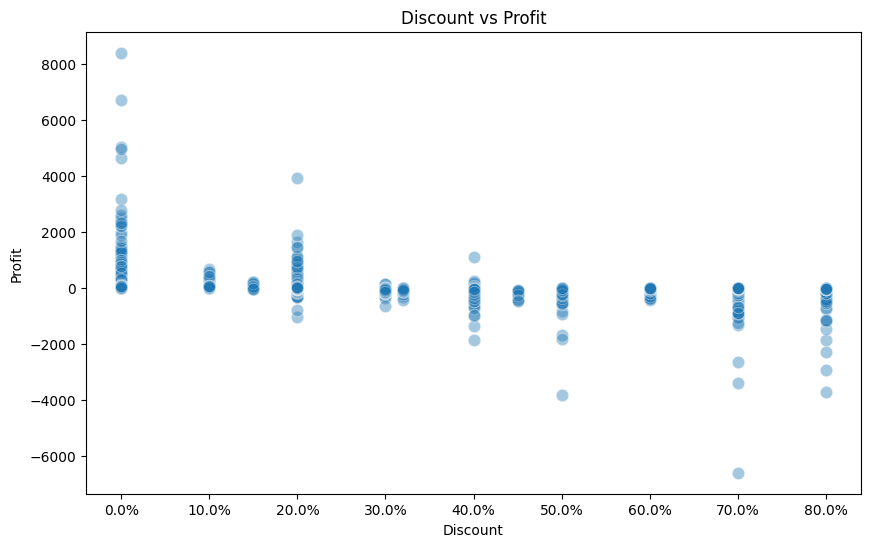

In [209]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='Discount', y='Profit', data=df_sales, s=80, alpha=0.4)

ax.set_title("Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1))

fig = ax.get_figure()
fig.savefig("../Images/discount_vs_profit.png", dpi = 300, bbox_inches='tight')

plt.show()

## 2.3. Loss Analysis

In [210]:
df_sales.loc[:, 'Profit Flag'] = df_sales.loc[:,'Profit'].apply(lambda x: 'Loss' if x<0 else 'Profit')

In [211]:
df_sales.groupby('Profit Flag').agg(
    Avg_Discount=('Discount', 'mean')
)

,Avg_Discount
Profit Flag,
Loss,0.48
Profit,0.08


In [212]:
loss_df = df_sales.loc[df_sales['Profit'] < 0, :].copy()

In [213]:
print(f"Total Loss: ${loss_df['Profit'].sum():,.0f}")

Total Loss: $-156,131


In [214]:
loss_df.groupby(['Sub-Category']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

,Total_Loss
Sub-Category,
Binders,"-38,510.50"
Tables,"-32,412.15"
Machines,"-30,118.67"
Bookcases,"-12,152.21"
Chairs,"-9,880.84"
Appliances,"-8,629.64"
Phones,"-7,530.62"
Furnishings,"-6,490.91"
Storage,"-6,426.30"


In [215]:
loss_df.groupby('Region').agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

,Total_Loss
Region,
Central,"-56,314.89"
East,"-49,590.61"
South,"-27,504.83"
West,"-22,720.96"


In [216]:
loss_df.groupby(['Category']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

,Total_Loss
Category,
Furniture,"-60,936.11"
Office Supplies,"-56,615.26"
Technology,"-38,579.92"


In [217]:
loss_df.groupby(['Segment']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

,Total_Loss
Segment,
Consumer,"-84,945.71"
Corporate,"-44,787.21"
Home Office,"-26,398.37"


In [218]:
loss_df.groupby(['Discount Group']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

,Total_Loss
Discount Group,
60-80%,"-70,614.40"
20-40%,"-38,956.65"
40-60%,"-28,944.19"
1-20%,"-17,616.04"


In [219]:
Total_Loss_SubCat = loss_df.groupby(['Sub-Category']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss').head(10)

<function matplotlib.pyplot.show(close=None, block=None)>

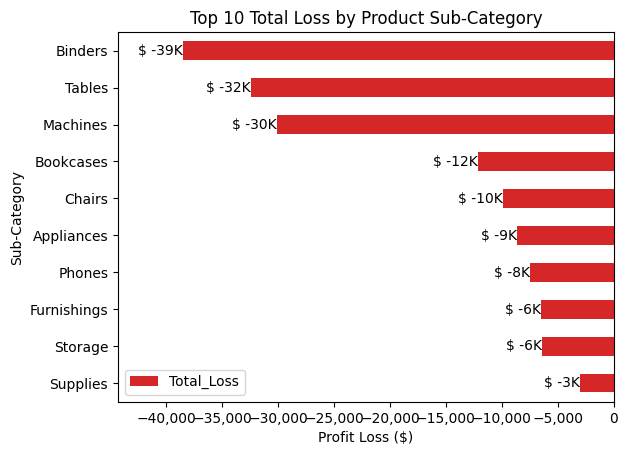

In [220]:
ax = Total_Loss_SubCat.sort_values(by="Total_Loss", ascending=False).plot(kind='barh', color=colors)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title("Top 10 Total Loss by Product Sub-Category")
ax.set_xlabel("Profit Loss ($)")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'$ {v/1000:,.0f}K' for v in container.datavalues]
    ax.bar_label(container, labels = labels)

fig = ax.get_figure()
fig.savefig("../Images/top_total_loss_by_product_subcategory.png", dpi = 300, bbox_inches='tight')

plt.show

### The top 10 loss-making sub-categories account for more than USD 150K in total losses.  
### The top three which is Binders, Tables, and Machines contribute approximately 65% of total losses (~USD 100K).  

In [221]:
Total_Loss_Segment = loss_df.groupby(['Segment']).agg(
    Total_Loss=('Profit', 'sum'),
).sort_values(by='Total_Loss')

<function matplotlib.pyplot.show(close=None, block=None)>

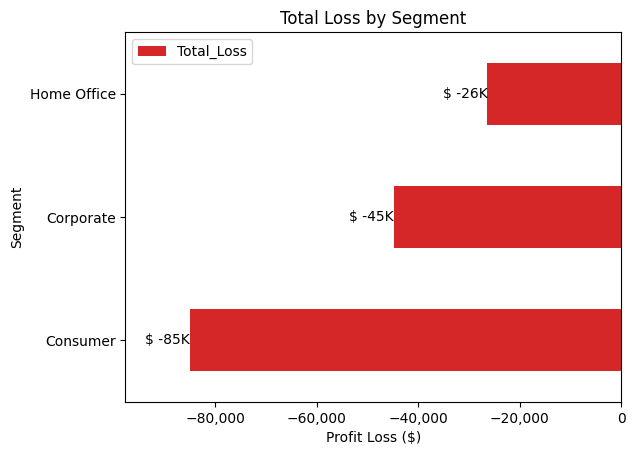

In [222]:
ax = Total_Loss_Segment.plot(kind='barh', color=colors)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title("Total Loss by Segment")
ax.set_xlabel("Profit Loss ($)")
ax.margins(x=0.15)

for container in ax.containers:
    labels = [f'$ {v/1000:,.0f}K' for v in container.datavalues]
    ax.bar_label(container, labels = labels)

fig = ax.get_figure()
fig.savefig("../Images/top_total_loss_by_customer_segment.png", dpi = 300, bbox_inches='tight')

plt.show

## 2.4. Product Portofolio

In [223]:
portofolio = df_sales.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

portofolio['Margin'] = portofolio['Total_Profit'] / portofolio['Total_Sales']

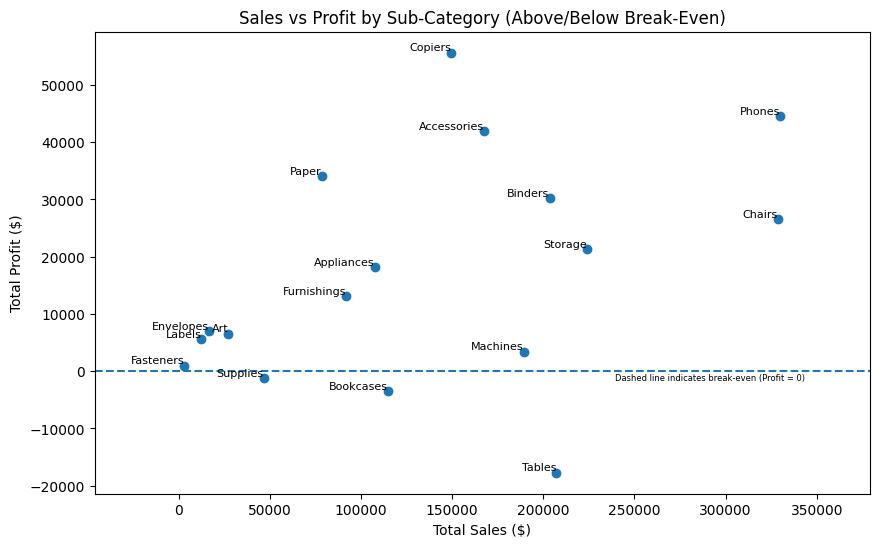

In [224]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Sales', y='Total_Profit', data=portofolio, s=60)

for i in portofolio.index:
    plt.text(
        portofolio.loc[i, 'Total_Sales'],
        portofolio.loc[i, 'Total_Profit'],
        i,
        fontsize=8,
        va='bottom',
        ha='right'
    )

plt.axhline(0, linestyle='--')
plt.title("Sales vs Profit by Sub-Category (Above/Below Break-Even)")
plt.suptitle('Dashed line indicates break-even (Profit = 0)', y=0.31, x=0.74, fontsize=6)
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")
plt.margins(x=0.15)
plt.savefig("../Images/sales_vs_profit_by_subcategory.png", dpi = 300, bbox_inches='tight')
plt.show()

In [225]:
median_sales = portofolio['Total_Sales'].median()
median_profit = portofolio['Total_Profit'].median()

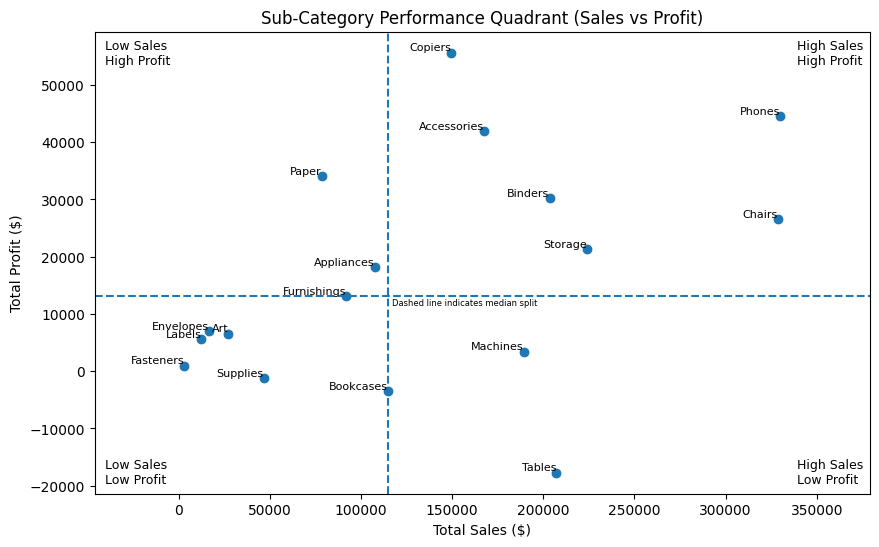

In [226]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Sales', y='Total_Profit', data=portofolio, s=60)

for i in portofolio.index:
    plt.text(
        portofolio.loc[i, 'Total_Sales'],
        portofolio.loc[i, 'Total_Profit'],
        i,
        fontsize=8,
        va='bottom',
        ha='right'
    )

plt.axhline(median_profit, linestyle='--')
plt.axvline(median_sales, linestyle='--')
plt.text(median_sales*2.95, median_profit*4.10, 'High Sales\nHigh Profit', fontsize=9)
plt.text(median_sales*2.95, median_profit*-1.5, 'High Sales\nLow Profit', fontsize=9)
plt.text(median_sales*-0.35, median_profit*4.10, 'Low Sales\nHigh Profit', fontsize=9)
plt.text(median_sales*-0.35, median_profit*-1.5, 'Low Sales\nLow Profit', fontsize=9)
plt.title("Sub-Category Performance Quadrant (Sales vs Profit)")
plt.suptitle('Dashed line indicates median split', y=0.435, x=0.495, fontsize=6)
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")
plt.margins(x=0.15)
plt.savefig("../Images/subcategory_performance_quadrant.png", dpi = 300, bbox_inches='tight')
plt.show()

In [227]:
def classify(row):
    if row['Total_Sales'] >= median_sales and row['Total_Profit'] >= median_profit:
        return "Core"
    elif row['Total_Sales'] >= median_sales and row['Total_Profit'] < median_profit:
        return "Revenue Driver, Low Profit"
    elif row['Total_Sales'] < median_sales and row['Total_Profit'] >= median_profit:
        return "Niche High Profit"
    else:
        return "Low Performance"

In [228]:
portofolio.loc[:, 'Portofolio Class'] = portofolio.apply(classify, axis=1)

In [229]:
portofolio.head()

,Total_Sales,Total_Profit,Margin,Portofolio Class
Sub-Category,,,,
Accessories,"167,380.32","41,936.64",0.25,Core
Appliances,"107,532.16","18,138.01",0.17,Niche High Profit
Art,"27,118.79","6,527.79",0.24,Low Performance
Binders,"203,412.73","30,221.76",0.15,Core
Bookcases,"114,880.00","-3,472.56",-0.03,"Revenue Driver, Low Profit"


In [230]:
portofolio.groupby('Portofolio Class').agg(
    Margin=('Margin', 'mean'),
    Total_Sales=('Total_Sales', 'sum'),
    Total_Profit=('Total_Profit', 'sum')
)

,Margin,Total_Sales,Total_Profit
Portofolio Class,,,
Core,0.18,"1,402,620.85","220,160.95"
Low Performance,0.28,"105,779.32","18,798.64"
Niche High Profit,0.25,"277,716.53","65,250.72"
"Revenue Driver, Low Profit",-0.03,"511,084.16","-17,813.28"


### Portofolio analysis reveals a structural imbalance between revenue scale and profitability.  
### While the core sub-categories segment contribute the largest share of both sales and profit, the Revenue driver segment generates substantial revenue but operates at a negtavie margin, indicating potential pricing or cost inefficiencies.  
### Conversely, Niche High Profit and Low Performance segments exhibit the highest margins despite the lower sales volumes, suggesting strong unit economics but limited market scale.

## 2.5. Financial trend Overtime

In [231]:
df_sales[['Order Date', 'Ship Date']].describe()

,Order Date,Ship Date
count,9994,9994
mean,2013-04-30 19:20:02.401440,2013-05-04 18:20:49.229537
min,2011-01-04 00:00:00,2011-01-08 00:00:00
25%,2012-05-23 00:00:00,2012-05-27 00:00:00
50%,2013-06-27 00:00:00,2013-06-30 00:00:00
75%,2014-05-15 00:00:00,2014-05-19 00:00:00
max,2014-12-31 00:00:00,2015-01-06 00:00:00


In [232]:
monthly = df_sales.set_index('Order Date').resample('ME').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Discount=('Discount', 'mean')
)

monthly.loc[:, 'Margin'] = monthly.loc[:, 'Profit'] / monthly.loc[:, 'Sales']

In [233]:
monthly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2011-01-31 to 2014-12-31
Freq: ME
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sales     48 non-null     float64
 1   Profit    48 non-null     float64
 2   Discount  48 non-null     float64
 3   Margin    48 non-null     float64
dtypes: float64(4)
memory usage: 1.9 KB


In [234]:
print(type(monthly.index))

<class 'pandas.DatetimeIndex'>


In [235]:
monthlyPlot = monthly.copy()
monthlyPlot.index = monthlyPlot.index.to_pydatetime() 
monthlyPlot.index = monthlyPlot.index.strftime('%b %Y')

In [236]:
step = 6
ticks = list(range(0, len(monthlyPlot), step))

if ticks[-1] != len(monthlyPlot)-1:
    ticks.append(len(monthlyPlot)-1)

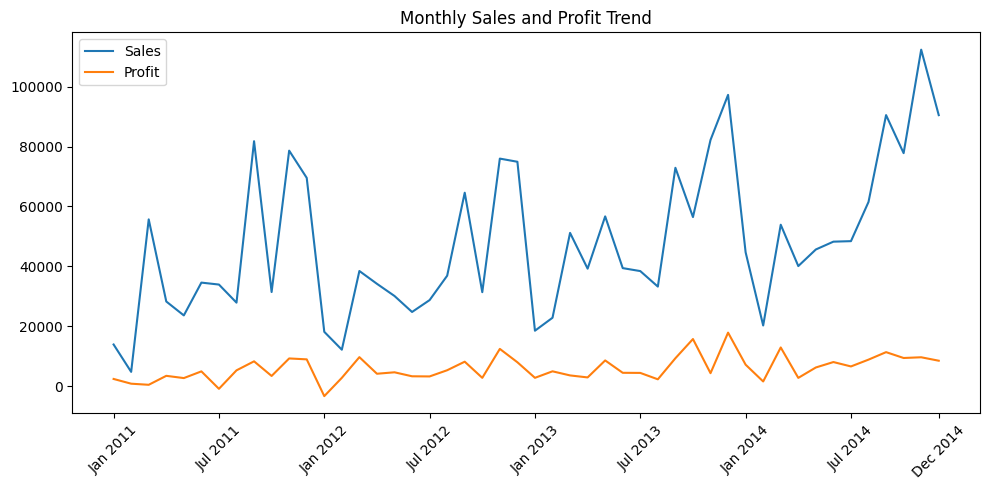

In [237]:
ax = monthlyPlot[['Sales', 'Profit']].plot(figsize=(10,5))
ax.set_xticks(ticks)
ax.set_xticklabels(monthlyPlot.index[ticks], rotation=45)
ax.set_title("Monthly Sales and Profit Trend")
fig = ax.get_figure()
fig.savefig("../Images/monthly_sales_and_profit_trend.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

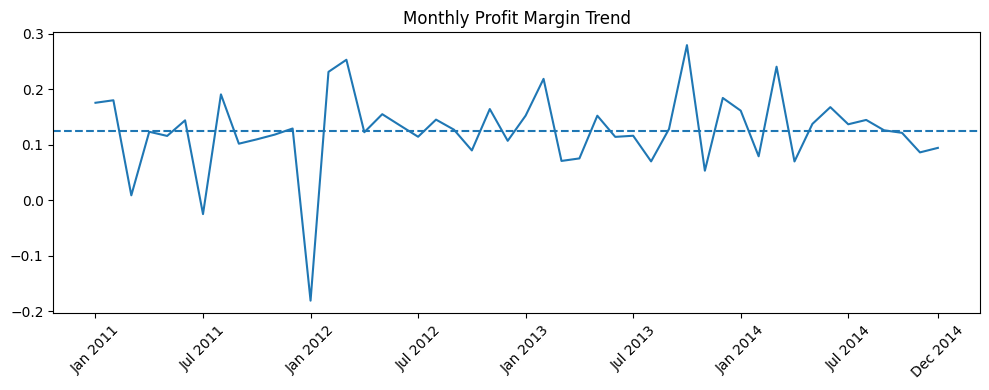

In [238]:
ax = monthlyPlot['Margin'].plot(figsize=(10,4))
ax.set_xticks(ticks)
ax.set_xticklabels(monthlyPlot.index[ticks], rotation=45)
plt.axhline(monthly['Margin'].mean(), linestyle='--')
plt.title("Monthly Profit Margin Trend")
fig = ax.get_figure()
fig.savefig("../Images/monthly_profit_margin_trend.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

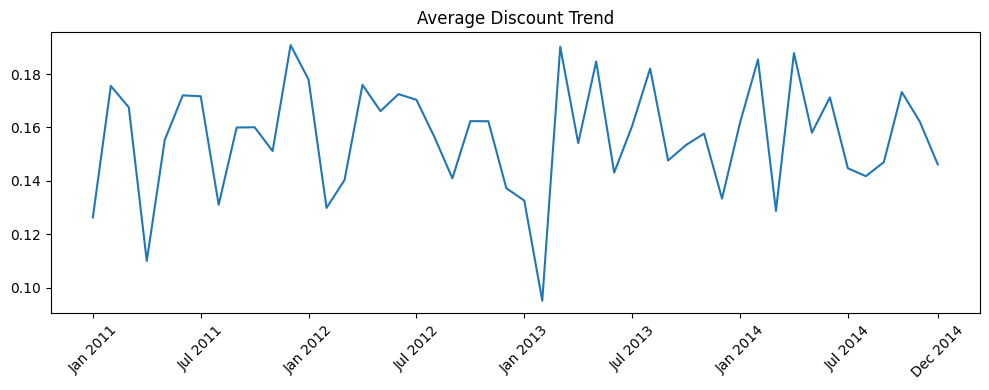

In [239]:
ax = monthlyPlot['Discount'].plot(figsize=(10,4))
ax.set_xticks(ticks)
ax.set_xticklabels(monthlyPlot.index[ticks], rotation=45)
plt.title("Average Discount Trend")
plt.tight_layout()
plt.show()

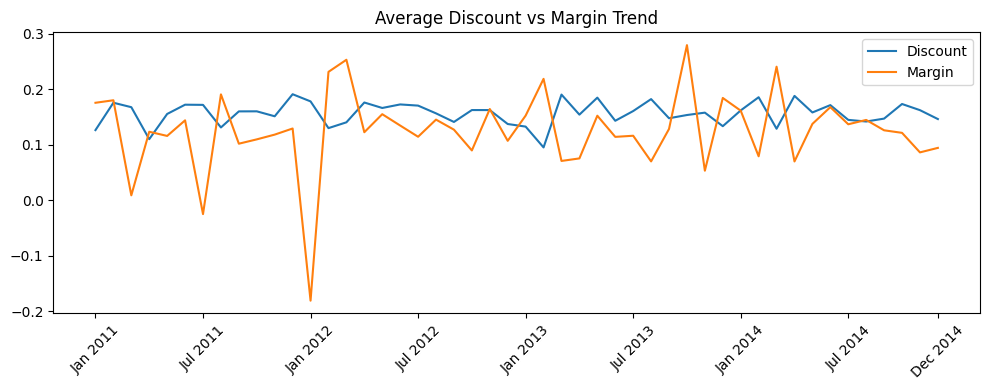

In [240]:
ax = monthlyPlot[['Discount', 'Margin']].plot(figsize=(10,4))
ax.set_xticks(ticks)
ax.set_xticklabels(monthlyPlot.index[ticks], rotation=45)
plt.title("Average Discount vs Margin Trend")
fig = ax.get_figure()
fig.savefig("../Images/discount_vs_margin_monthly_trend.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [241]:
df_sales.loc[:, 'Loss'] = df_sales.loc[:, 'Profit'].apply(lambda x: x if x<0 else 0)

In [242]:
monthly_loss = df_sales.set_index('Order Date').resample('ME')['Loss'].sum()

In [243]:
monthly_loss.describe()

count        48.00
mean     -3,252.74
std       2,498.08
min     -11,309.75
25%      -4,448.65
50%      -2,512.03
75%      -1,552.49
max        -101.37
Name: Loss, dtype: float64

In [244]:
monthly_lossPlot = monthly_loss.copy()
monthly_lossPlot.index = monthly_lossPlot.index.to_pydatetime() 
monthly_lossPlot.index = monthly_lossPlot.index.strftime('%b %Y')

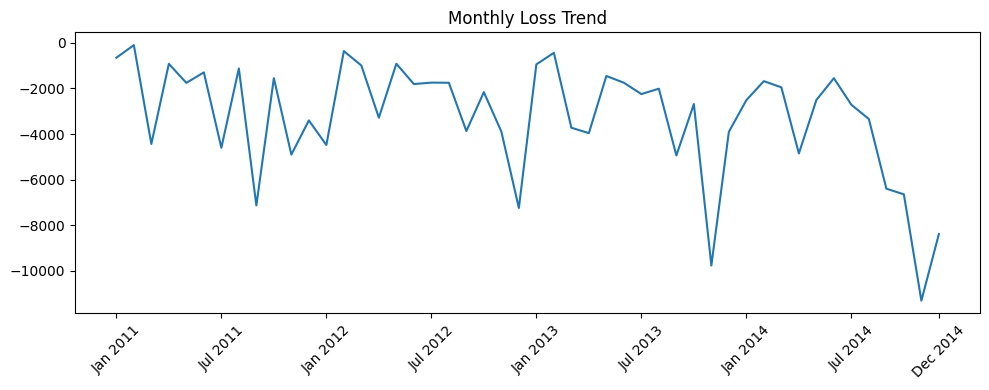

In [245]:
ax = monthly_lossPlot.plot(figsize=(10,4))
ax.set_xticks(ticks)
ax.set_xticklabels(monthly_lossPlot.index[ticks], rotation=45)
plt.title("Monthly Loss Trend")
fig = ax.get_figure()
fig.savefig("../Images/monthly_loss_trend.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [246]:
yearly = df_sales.resample('YE', on='Order Date').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
)

yearly['Margin'] = yearly['Profit'] / yearly['Sales']

In [247]:
yearly

,Sales,Profit,Margin
Order Date,,,
2011-12-31,"484,247.50","49,543.97",0.10
2012-12-31,"470,532.51","61,618.60",0.13
2013-12-31,"608,473.83","81,726.93",0.13
2014-12-31,"733,947.02","93,507.51",0.13


In [248]:
yearlyPlot = yearly.copy()
yearlyPlot.index = yearlyPlot.index.to_pydatetime() 
yearlyPlot.index = yearlyPlot.index.strftime('%b %Y')

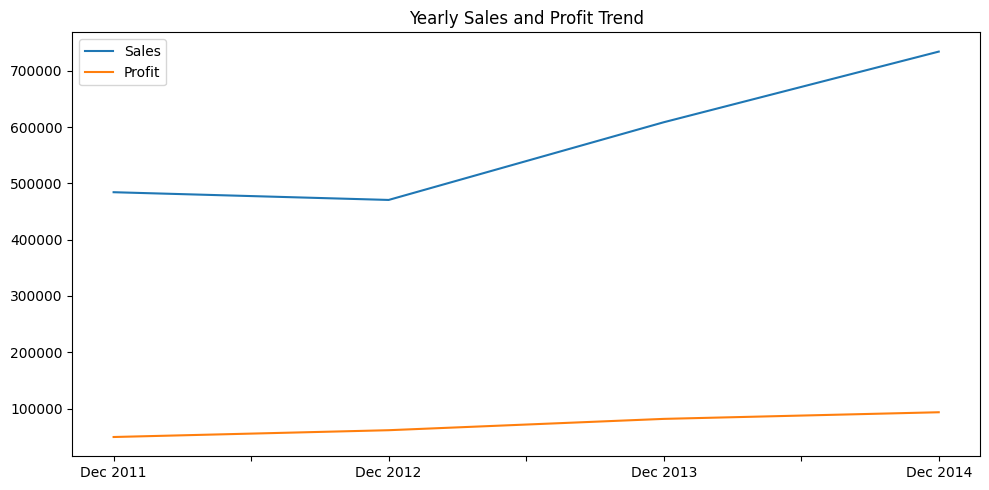

In [249]:
ax = yearlyPlot[['Sales', 'Profit']].plot(figsize=(10,5))
ax.set_title("Yearly Sales and Profit Trend")
fig = ax.get_figure()
fig.savefig("../Images/yearly_sales_and_profit_trend.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Overall, the revenue trend shows growth over observed period, indicating expansion in sales volume.
### However, profit growth does not always align with revenue growth, as reflected in margin fluctuations.
### In certain periods, margin declines coincided with increases in average discounts, indicating pressure on profitability.
### Monthly loss trends also show episodes of increased losses, likely related to discount strategies or the composition of products sold during those periods.

# -----------------------------------------------------

# Key Insights

### High sales volume does not necessarily translate into profitability, particularly in Tables and Bookcases.
### Higher discount levels are associated with lower profit and increased losses.
### Losses are concentrated in a small number of sub-categories, with Binders, Tables, and Machines contributing the majority.
### The product portfolio shows imbalance, where some high-revenue segments operate at negative margins.
### Revenue growth over time is not consistently mathced by profit growth, indicating margin pressure